# xarrayrf: reference frames and coordinate transformations for xarray

xarrayrf associates xarray `DataArray` objects with reference frames and mappings from array
coordinates to frame coordinates. These mappings support geometric queries, compatibility
checks, and resampling between grids. The examples show frame bindings through selection,
arithmetic, Dataset operations, and serialization. Operations that combine incompatible framed
coordinate mappings raise `ValueError`.

The notebook uses microscopy, MRI, and satellite datasets, followed by a synthetic scalar field
in spacetime. It distinguishes three operations: declaring frame identity, changing coordinate
conventions within a frame, and applying a transformation between different frames. Familiarity
with NumPy arrays and xarray dimensions and coordinates is assumed.

**Execution requirements.** Run the cells in order in the patched-xarray environment specified
below. The MRI data, brain images, atlas, and histology image are downloaded and cached locally;
the OME-Zarr and GeoTIFF examples access remote datasets. Initial downloads and remote dataset
access require a network connection. The serialization example writes to a temporary directory.

```sh
git clone https://github.com/matthiasschabel/xarrayrf && cd xarrayrf
uv sync --extra dev --group patched --group docs
uv run --group patched --group docs --with jupyterlab jupyter lab examples/xarrayrf_tour.ipynb
```

In [1]:
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tour_data  # fetches and caches the MRI study
import xarray as xr
from matplotlib.colors import ListedColormap

import xarrayrf as xrf
import xarrayrf.native  # registers the .rf accessor
from xarrayrf import dicom, geotiff, ngff, nifti

workdir = Path(tempfile.mkdtemp())
BLUE, ORANGE = "#2a78d6", "#eb6834"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## 1. Reference frames and array geometry

This section defines an array-to-frame mapping and examines its behavior under selection and
arithmetic.

### 1.1. Defining an array-to-frame transform

A reference frame identifies the space in which coordinates are interpreted. A coordinate system
specifies its axes and units, and an array-to-frame transform maps array coordinates into that
system.

This example assigns an illustrative stage geometry to a stained tissue image: 0.5 µm pixel
spacing, a 10° rotation relative to the stage axes, and a translation of (1200, 800) µm. The
image shows colonic glands, with FHL2 staining in brown and nuclei in blue. The binding applies
to `row` and `column`; `rgb` is a non-geometric dimension.

In [2]:
stage = xrf.ReferenceFrame.local(xrf.CoordinateSystem(("x", "y"), ("um", "um")))
angle, pixel = np.deg2rad(10), 0.5
placement = xrf.AffineTransform(
    source=xrf.ArrayCoordinates(("row", "column"), ("1", "1")),
    target=stage,
    target_axes=("x", "y"),
    basis_vectors={
        "row": (-np.sin(angle) * pixel, np.cos(angle) * pixel),
        "column": (np.cos(angle) * pixel, np.sin(angle) * pixel),
    },
    translation=[1200.0, 800.0],
)
pixels = plt.imread(tour_data.tissue_section())[..., :3]
image = xr.DataArray(
    pixels,
    dims=("row", "column", "rgb"),
    name="section",
    coords={"row": np.arange(512), "column": np.arange(512), "rgb": ["red", "green", "blue"]},
).rf.frame(placement, dims=("row", "column"))
image

<xarray.DataArray 'section' (row: 512, column: 512, rgb: 3)> Size: 3MB
array([[[0.6117647 , 0.4627451 , 0.31764707],
        [0.6392157 , 0.49019608, 0.34509805],
        [0.6117647 , 0.45490196, 0.31764707],
        ...,
        [0.59607846, 0.627451  , 0.76862746],
        [0.6627451 , 0.6862745 , 0.8117647 ],
        [0.7411765 , 0.76862746, 0.88235295]],

       [[0.5529412 , 0.4117647 , 0.27058825],
        [0.5647059 , 0.42352942, 0.28235295],
        [0.5529412 , 0.4       , 0.27058825],
        ...,
        [0.6431373 , 0.6745098 , 0.8156863 ],
        [0.654902  , 0.6784314 , 0.8039216 ],
        [0.6862745 , 0.7137255 , 0.8235294 ]],

       [[0.49019608, 0.36078432, 0.23137255],
        [0.5176471 , 0.3882353 , 0.25882354],
        [0.5411765 , 0.40392157, 0.2784314 ],
        ...,
...
        [0.83137256, 0.827451  , 0.8117647 ],
        [0.8392157 , 0.8235294 , 0.8117647 ],
        [0.8509804 , 0.8352941 , 0.8235294 ]],

       [[0.8509804 , 0.8392157 , 0.8117647 ],
        [0.87058824, 0.85882354, 0.83137256],
        [0.9019608 , 0.8901961 , 0.8627451 ],
        ...,
        [0.8392157 , 0.8352941 , 0.827451  ],
        [0.827451  , 0.8117647 , 0.8       ],
        [0.84313726, 0.8235294 , 0.8117647 ]],

       [[0.87058824, 0.85882354, 0.83137256],
        [0.87058824, 0.85882354, 0.83137256],
        [0.8784314 , 0.8666667 , 0.8392157 ],
        ...,
        [0.8235294 , 0.81960785, 0.8117647 ],
        [0.8235294 , 0.8039216 , 0.7921569 ],
        [0.84313726, 0.8235294 , 0.8117647 ]]],
      shape=(512, 512, 3), dtype=float32)
Coordinates:
  * row      (row) int64 4kB 0 1 2 3 4 5 6 7 ... 504 505 506 507 508 509 510 511
  * column   (column) int64 4kB 0 1 2 3 4 5 6 7 ... 505 506 507 508 509 510 511
  * rgb      (rgb) <U5 60B 'red' 'green' 'blue'
Indexes:
  ┌ row      BindingIndex
  └ column

The following operation applies an intensity power transformation, crops the image, and retains
every second sample along each spatial dimension. The geometric query compares the first
retained pixel with its corresponding pixel in the original array. The plot displays both arrays
in stage coordinates.

In [3]:
view = (image**0.6).isel(row=slice(120, 380, 2), column=slice(200, 460, 2))

print("view:", dict(view.sizes))
print(
    "first retained pixel (stage coordinates):",
    view.rf.geometry.point_at(row=0, column=0).values.round(2),
    "µm",
)
print(
    "source pixel (120, 200) (stage coordinates):",
    image.rf.geometry.point_at(row=120, column=200).values.round(2),
    "µm",
)

view: {'row': 130, 'column': 130, 'rgb': 3}
first retained pixel (stage coordinates): [1288.06  876.45] µm
source pixel (120, 200) (stage coordinates): [1288.06  876.45] µm


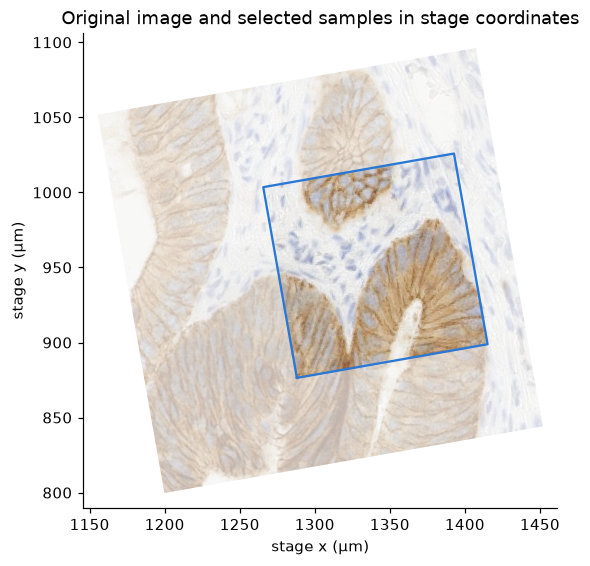

In [4]:
from matplotlib.transforms import Affine2D


def place(ax, array, **style):
    """Display an RGB array in stage coordinates."""
    to_stage = Affine2D(array.rf.geometry.lattice(("column", "row")).affine)
    rows, columns = array.sizes["row"], array.sizes["column"]
    ax.imshow(
        np.clip(array.transpose("row", "column", "rgb").values, 0, 1),
        extent=(-0.5, columns - 0.5, rows - 0.5, -0.5),
        transform=to_stage + ax.transData,
        **style,
    )
    corners = np.array([[0, 0], [0, columns - 1], [rows - 1, columns - 1], [rows - 1, 0], [0, 0]])
    return array.rf.geometry.lattice().transform_point(corners)


fig, ax = plt.subplots(figsize=(6, 5.6))
outline = place(ax, image, alpha=0.35)
crop = place(ax, view)
ax.plot(*crop.T, color=BLUE, lw=1.5)
ax.set(
    xlim=(outline[:, 0].min() - 10, outline[:, 0].max() + 10),
    ylim=(outline[:, 1].min() - 10, outline[:, 1].max() + 10),
    aspect="equal",
    xlabel="stage x (µm)",
    ylabel="stage y (µm)",
    title="Original image and selected samples in stage coordinates",
)
plt.show()

Image source: scikit-image `immunohistochemistry` sample, Center for Microscopy and Molecular
Imaging; no known copyright restrictions. Pixel spacing, rotation, and translation are assigned
for this example and are not measured properties of the image.

### 1.2. Frame compatibility and explicit frame assumptions

Frames with identical axes and units can have distinct identities. In the following example,
addition of arrays in two distinct local frames raises `ValueError`. Multiplication by an
unframed mask with matching labels retains the image's binding.

`assume_frame` declares that two frames identify the same space; it does not estimate a
registration. Here, the two arrays also have matching coordinate mappings, so addition is
permitted after the explicit assumption.

In [5]:
elsewhere = xrf.ReferenceFrame.local(stage.coordinate_system)  # another slide, same axes
other = image.rf.unframe().rf.frame(
    xrf.AffineTransform.from_matrix(
        source=placement.source,
        target=elsewhere,
        matrix=placement.matrix,
        translation=placement.translation,
    ),
    dims=("row", "column"),
)

try:
    image + other
except ValueError as error:
    print("ValueError:", error)

mask = xr.ones_like(image.rf.unframe())  # a plain DataArray, same labels
print("binding retained after multiplication by unframed mask:", (image * mask).rf.is_framed)
print(
    "binding retained after explicit frame assumption:",
    (image + other.rf.assume_frame(image)).rf.is_framed,
)

ValueError: incompatible framed coordinate mappings: the operands are in different reference frames (xarrayrf.local:c939724c2e024446b92b22348b51da72 and xarrayrf.local:776a8137f7144c0bb3d539d9fb64f40b); resample one onto the other with a transform between the frames, or use rf.assume_frame if they are the same space
binding retained after multiplication by unframed mask: True
binding retained after explicit frame assumption: True


## 2. Multiscale microscopy with OME-Zarr

The Image Data Resource (IDR) dataset below is a confocal mouse-tissue volume stored in a public
OME-Zarr repository. It contains 236 planes and two channels: Lamin B1, marking the nuclear
envelope, and DAPI, marking DNA. Spatial coordinates are expressed in micrometres. With the
default lazy reader, opening the dataset loads metadata and defers image-value access until
computation.

In [6]:
IDR_TISSUE = "https://uk1s3.embassy.ebi.ac.uk/idr/zarr/v0.4/idr0062A/6001240.zarr"
tissue = ngff.open(IDR_TISSUE)
lattice = tissue.rf.geometry.lattice()
print(dict(tissue.sizes), "| lazy:", type(tissue.data).__name__)
print("voxel size (z, y, x):", lattice.spacing.round(3), "µm")

{'c': 2, 'z': 236, 'y': 275, 'x': 271} | lazy: Array
voxel size (z, y, x): [0.5  0.36 0.36] µm


Selecting `z=118` retains the plane's position in the volume's reference frame. Calling
`compute()` retrieves the storage chunks needed for that plane.

In [7]:
plane = tissue.isel(z=118).compute()
print(
    "selected plane (z=118), frame z coordinate:",
    plane.rf.geometry.point_at(y=0, x=0).values[0].round(2),
    "µm",
)

selected plane (z=118), frame z coordinate: 59.02 µm


The resolution levels in this OME-Zarr dataset share a reference frame but use different
sampling grids. Direct addition of the two levels raises `ValueError`. The example uses
`resample_to` to interpolate a slab from level 1 onto the corresponding full-resolution grid
before displaying the images side by side.

In [8]:
coarse = ngff.open(IDR_TISSUE, level="1")  # 2x downsampled in y and x
print("levels:", dict(tissue.sizes), "and", dict(coarse.sizes))
try:
    tissue + coarse
except ValueError as error:
    print("ValueError:", error)

slab = dict(z=slice(110, 127))
upsampled = coarse.isel(slab).rf.resample_to(tissue.isel(slab)).compute()

levels: {'c': 2, 'z': 236, 'y': 275, 'x': 271} and {'c': 2, 'z': 236, 'y': 137, 'x': 135}
ValueError: incompatible framed coordinate mappings: the operands sample the same frame on different grids; resample one onto the other with rf.resample_to


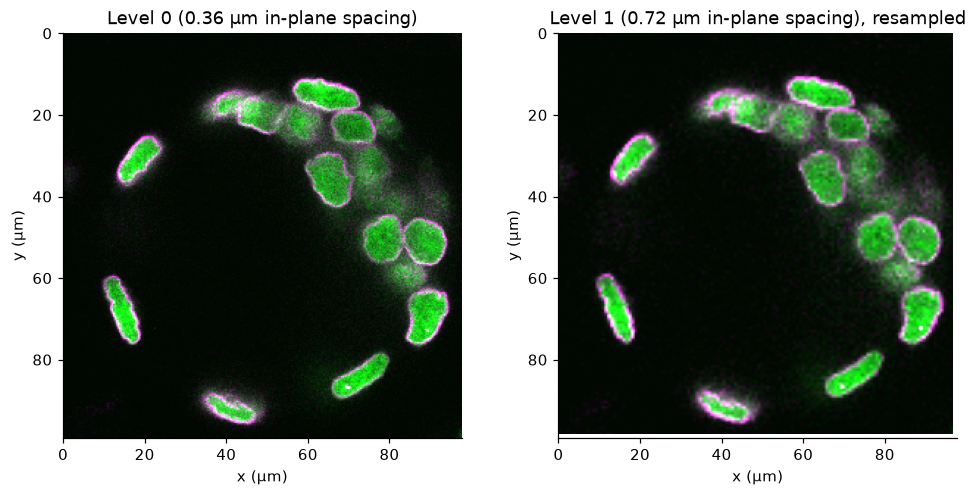

In [9]:
def composite(image):
    """Lamin B1 in magenta, DAPI in green, each scaled to its 99.5th percentile."""
    lamin, dapi = (np.clip(image.isel(c=c) / image.isel(c=c).quantile(0.995), 0, 1) for c in (0, 1))
    return np.stack([lamin, dapi, lamin], axis=-1)


height, width = plane.sizes["y"] * lattice.spacing[1], plane.sizes["x"] * lattice.spacing[2]
extent = [0, float(width), float(height), 0]
fig, axes = plt.subplots(1, 2, figsize=(9, 4.4), constrained_layout=True)
panels = [
    (plane, "Level 0 (0.36 µm in-plane spacing)"),
    (upsampled.isel(z=8), "Level 1 (0.72 µm in-plane spacing), resampled"),
]
for ax, (shown, title) in zip(axes, panels, strict=True):
    ax.imshow(composite(shown), extent=extent)
    ax.set(title=title, xlabel="x (µm)", ylabel="y (µm)")
plt.show()

The lattice affine specifies the image geometry when constructing a napari layer, without
separate `scale` or `translate` values:

```python
import napari

viewer = napari.Viewer()
viewer.add_image(tissue.data, channel_axis=0, name=["Lamin B1", "DAPI"],
                 colormap=["magenta", "green"], affine=lattice.affine)
```

For the displayed composites, Lamin B1 is shown in magenta and DAPI in green; each channel is
scaled independently by its 99.5th percentile.

Data source: IDR idr0062, Blin et al., *PLOS Biology* (2019), CC BY 4.0.

## 3. MRI geometry and resampling

The following examples distinguish acquisition geometry, coordinate conventions, anatomical
orientation, and geometric queries.

### 3.1. DICOM series in a shared patient frame

The example uses three T2-weighted HASTE series from one imaging session of a pregnant non-human
primate, acquired in coronal, sagittal, and axial orientations. The de-identified dataset
includes DICOM files and corresponding NIfTI conversions produced by `dcm2niix` (approximately
29 MB, CC BY 4.0).

The DICOM reader loads metadata and constructs lazy pixel arrays. The reader derives frame
identity from the DICOM `FrameOfReferenceUID`; the printed comparison checks that the three
series share this identity.

In [10]:
study_dir = tour_data.mri_study()
coronal = dicom.open(study_dir / "dicom" / "t2_haste_cor_pat2")
sagittal = dicom.open(study_dir / "dicom" / "t2_haste_sag_pat2")
axial = dicom.open(study_dir / "dicom" / "t2_haste_axial_pat2")

for name, series in [("coronal", coronal), ("sagittal", sagittal), ("axial", axial)]:
    print(f"{name:9s}", dict(series.sizes))
print(
    "shared reference-frame identity:",
    coronal.rf.reference_frame == sagittal.rf.reference_frame == axial.rf.reference_frame,
)

coronal   {'k': 84, 'j': 320, 'i': 160}
sagittal  {'k': 80, 'j': 320, 'i': 160}
axial     {'k': 72, 'j': 160, 'i': 320}
shared reference-frame identity: True


The three series have different sampling grids in a shared patient frame. `resample_to`
interpolates the sagittal and axial series onto the coronal grid, after which the arrays can be
combined in a Dataset. Linear interpolation is used by default; target samples outside the
source domain receive NaN. The displayed average is computed over available values
(`skipna=True`).

Point resampling between these differently oriented grids does not retain the acquired slice
intervals. To compare values on common coordinates, the coronal display copy omits its interval
declaration while retaining the frame and coordinate mapping. The original `coronal` array
retains its slice intervals for slab averaging below. The voxelwise mean is a value comparison,
not an average over a combined acquisition support.

Sharing a patient frame does not establish anatomical correspondence across acquisitions.
Differences may reflect motion between acquisitions and the 2 mm slice sampling. This example
resamples the recorded acquisition geometries; it does not perform motion correction.

In [11]:
sagittal_on_coronal = sagittal.rf.resample_to(coronal).compute()  # lazy until computed
axial_on_coronal = axial.rf.resample_to(coronal).compute()

coronal = coronal.compute()
coronal_values = coronal.rf.unframe().rf.frame(
    coronal.rf.coordinate_transform, dims=coronal.rf.geometry_dims
)
views = xr.Dataset(
    {"coronal": coronal_values, "sagittal": sagittal_on_coronal, "axial": axial_on_coronal}
)
views["average"] = views.to_dataarray("view").mean("view", skipna=True)
print({name: views[name].rf.is_framed for name in views.data_vars})

{'coronal': True, 'sagittal': True, 'axial': True, 'average': True}


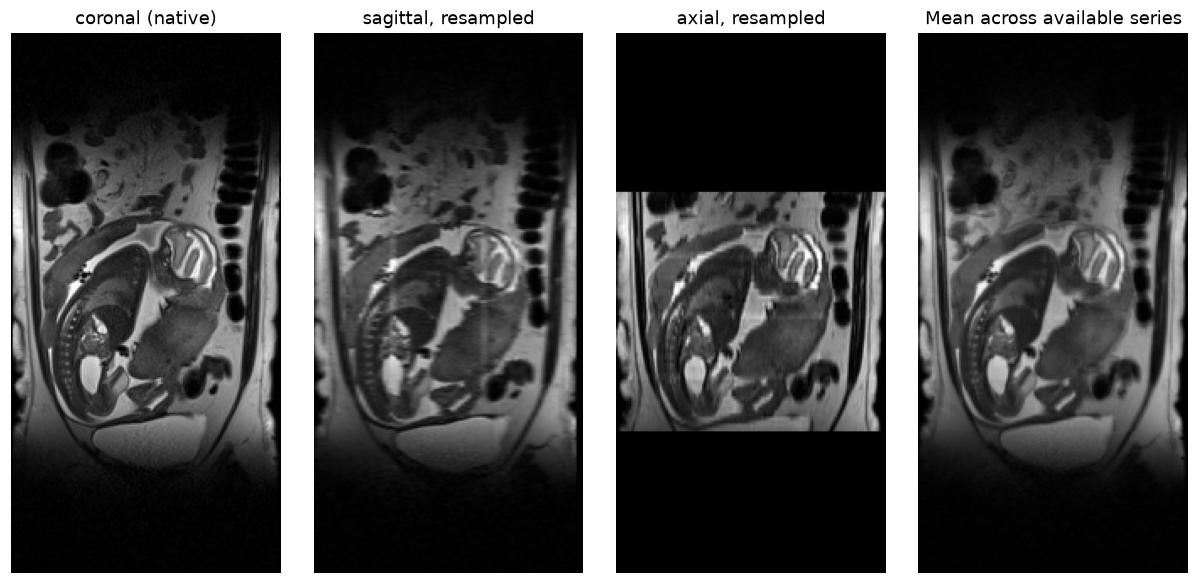

In [12]:
gray = plt.get_cmap("gray").with_extremes(bad="black")
fig, axes = plt.subplots(1, 4, figsize=(11, 5.2), constrained_layout=True)
middle = dict(k=42)
top = float(views.coronal.quantile(0.995))
titles = {
    "coronal": "coronal (native)",
    "sagittal": "sagittal, resampled",
    "axial": "axial, resampled",
    "average": "Mean across available series",
}
for ax, (name, title) in zip(axes, titles.items(), strict=True):
    ax.imshow(views[name].isel(middle), cmap=gray, vmin=0, vmax=top)
    ax.set_title(title)
    ax.set_axis_off()
plt.show()

### 3.2. Coordinate conventions and frame identity in NIfTI

The converted NIfTI files use right–anterior–superior (RAS) coordinates, whereas the DICOM
reader uses left–posterior–superior (LPS) coordinates. Their array layouts also differ. The
NIfTI geometry does not identify the DICOM reference frame, so this file is initially assigned
an anonymous frame. Resampling it onto the DICOM grid without an explicit frame relationship
raises `ValueError`.

In [13]:
unnamed = nifti.open(study_dir / "nifti" / "t2_haste_cor.nii.gz")
print("anonymous frame:", unnamed.rf.reference_frame.is_anonymous)
try:
    unnamed.rf.resample_to(coronal)
except ValueError as error:
    print("ValueError:", error)

anonymous frame: True
ValueError: different reference frames; source operand is anonymous; the grids differ; assert the shared world with frame= or rf.assume_frame, then use rf.resample_to


Because this NIfTI file was converted from the same DICOM series, the example supplies
`frame=coronal` when opening it. `rf.assume_frame` can make the corresponding declaration after
opening. RAS and LPS differ by known axis flips, which xarrayrf applies during the
coordinate-system conversion. The caller supplies the frame-identity declaration.

The following comparison resamples the NIfTI data onto the DICOM grid and reports the maximum
absolute intensity difference. Small discrepancies can arise from finite precision in the stored
affine and interpolation; this diagnostic does not isolate their causes.

In [14]:
coronal_nifti = nifti.open(study_dir / "nifti" / "t2_haste_cor.nii.gz", frame=coronal)
print("NIfTI layout:", dict(coronal_nifti.sizes), "  DICOM layout:", dict(coronal.sizes))

difference = coronal_nifti.rf.resample_to(coronal) - views.coronal
print(
    f"maximum absolute intensity difference: {float(abs(difference).max()):.2f}; maximum DICOM intensity: {int(views.coronal.max())}"
)

NIfTI layout: {'i': 160, 'j': 320, 'k': 84}   DICOM layout: {'k': 84, 'j': 320, 'i': 160}


maximum absolute intensity difference: 0.18; maximum DICOM intensity: 4038


### 3.3. Anatomical orientation and slice extent

`anatomy.orientation_codes` reports the anatomical direction associated with increasing indices
along each geometric dimension. The reader records DICOM `SliceThickness` as a declared slice
interval, separately from the distance between slice centres. The output compares these
quantities for the three series; they are equal in this dataset. For gapped or overlapping
acquisitions, slice thickness and centre-to-centre spacing differ.

In [15]:
from xarrayrf import anatomy

for name, series in [("coronal", coronal), ("sagittal", sagittal), ("axial", axial)]:
    grid = series.rf.grid  # Sampling grid without image values
    spacing = float(series.rf.geometry.lattice().spacing[0])  # mm between slice centres
    lo, hi = grid.intervals["k"][0]  # declared cell of the first slice, in index units
    print(
        f"{name:9s} {anatomy.orientation_codes(grid)}  slices {spacing:.1f} mm apart, "
        f"{(hi - lo) * spacing:.1f} mm thick"
    )

coronal   PIL  slices 2.0 mm apart, 2.0 mm thick
sagittal  RIP  slices 2.0 mm apart, 2.0 mm thick
axial     SPL  slices 2.0 mm apart, 2.0 mm thick


### 3.4. Point samples and slab averages

A point sample represents a value at a coordinate. A slab sample represents an average over a
declared interval. In MRI, slice thickness describes a nominal extent, which can differ from
centre-to-centre spacing. The examples here use a rectangular slice-profile model; the nominal
thickness does not determine an acquired MRI slice's full response profile.

Resampling specifies two separate choices: `method` constructs or selects a reconstruction from
the source, and `support` determines how that reconstruction is evaluated on the target.
`support="point"` evaluates target coordinates. With a box method, `support="average"` averages
over the covered portion of each declared target interval. Merely assigning intervals to a
target does not change the default linear point interpolation into slab averaging.

#### Controlled sampling examples

The following one-dimensional examples vary slice spacing and thickness independently. All use
the analytic signal

\[
f(z)=2+\sin(\pi z/5),
\]

with \(z\) in millimetres. Point values are evaluated at sample coordinates; slab values are
computed as the analytic mean over each declared source interval. Thus the inputs represent
different measurements of the same underlying function, rather than identical numbers with
different geometry metadata.

| Case | Slice centres | Declared thickness | Resampling method |
|---|---|---|---|
| Point samples | Every 2 mm | None (`sample_offset=None`) | `linear`, point support |
| Contiguous, evenly spaced slabs | Every 2 mm | 2 mm | `step`, point and average support |
| Gapped, evenly spaced slabs | Every 2 mm | 1 mm | `step`, point and average support |
| Overlapping, evenly spaced slabs | Every 2 mm | 3 mm | `overlap_mean`, point and average support |
| Uneven spacing and thickness | Centres of intervals with edges 0, 1.5, 4, 5, 8, 10 mm | Per-sample widths | `step`, point and average support |

`step` reconstructs a constant value within each non-overlapping slab and returns NaN in gaps.
`overlap_mean` takes the mean of all slabs covering a position; it does not reconstruct a unique
underlying signal from the overlapping measurements. Both methods average their reconstruction
over covered target support. `step` rejects overlapping intervals on an axis being resampled.

The default `linear` method remains available for slab data. It interpolates through the
measured values at the slice centres and bridges interior gaps, making a different
reconstruction assumption. Declaring source intervals does not change that default. Averaging
with `linear`, `nearest`, or `cubic` is not yet implemented.

In [16]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from xarrayrf.native import frame_array

profile_frame = xrf.ReferenceFrame.local(xrf.CoordinateSystem(("z",), ("mm",)))


def profile_grid(centres, intervals=None):
    """Declare sample positions and optional slab intervals in millimetres."""
    transform = xrf.AffineTransform.from_matrix(
        source=xrf.ArrayCoordinates(
            ("z",), ("mm",), sample_offset=(None if intervals is None else 0.5,)
        ),
        target=profile_frame,
        matrix=[[1.0]],
        translation=[0.0],
    )
    return xrf.Grid(
        transform,
        {"z": ("slice", np.asarray(centres, dtype=float))},
        intervals=None if intervals is None else {"z": intervals},
    )


def signal_at(z):
    return 2.0 + np.sin(np.pi * z / 5.0)


def signal_mean(intervals):
    centres = intervals.mean(axis=1)
    widths = intervals[:, 1] - intervals[:, 0]
    return 2.0 + np.sinc(widths / 10.0) * np.sin(np.pi * centres / 5.0)

In [17]:
regular_centres = np.arange(1.0, 10.0, 2.0)
irregular_edges = np.array([0.0, 1.5, 4.0, 5.0, 8.0, 10.0])
irregular_intervals = np.column_stack((irregular_edges[:-1], irregular_edges[1:]))
profiles = [
    ("Point samples", regular_centres, None, "linear"),
    ("Contiguous slabs", regular_centres, regular_centres[:, None] + [-1.0, 1.0], "step"),
    ("Gapped slabs", regular_centres, regular_centres[:, None] + [-0.5, 0.5], "step"),
    ("Overlapping slabs", regular_centres, regular_centres[:, None] + [-1.5, 1.5], "overlap_mean"),
    (
        "Uneven spacing and thickness",
        irregular_intervals.mean(axis=1),
        irregular_intervals,
        "step",
    ),
]

point_z = np.linspace(0.0, 10.0, 400)
point_target = profile_grid(point_z)
target_edges = np.linspace(0.0, 10.0, 5)
target_intervals = np.column_stack((target_edges[:-1], target_edges[1:]))
slab_target = profile_grid(target_intervals.mean(axis=1), target_intervals)
results = []
summary_rows = []

In [18]:
for name, centres, intervals, method in profiles:
    values = signal_at(centres) if intervals is None else signal_mean(intervals)
    source = frame_array(values, profile_grid(centres, intervals))
    centre_interpolant = source.rf.resample_to(point_target, method="linear")
    point_values = source.rf.resample_to(point_target, method=method, support="point")
    average, coverage = None, None
    if intervals is not None:
        average, coverage = source.rf.resample_to(
            slab_target,
            method=method,
            support="average",
            return_coverage=True,
        )
        for z, value, fraction in zip(
            average.z.values, average.values, coverage.values, strict=True
        ):
            summary_rows.append((name, z, value, fraction))
    results.append((name, source, intervals, centre_interpolant, point_values, average, coverage))

summary = pd.DataFrame(
    summary_rows, columns=["Source geometry", "Target centre (mm)", "Slab mean", "Coverage"]
)
gap_summary = summary.loc[
    summary["Source geometry"] == "Gapped slabs",
    ["Target centre (mm)", "Slab mean", "Coverage"],
]
gap_summary.round(4)

,Target centre (mm),Slab mean,Coverage
4,1.25,NaN,0.4
5,3.75,2.6237,0.6
6,6.25,1.3763,0.6
7,8.75,NaN,0.4


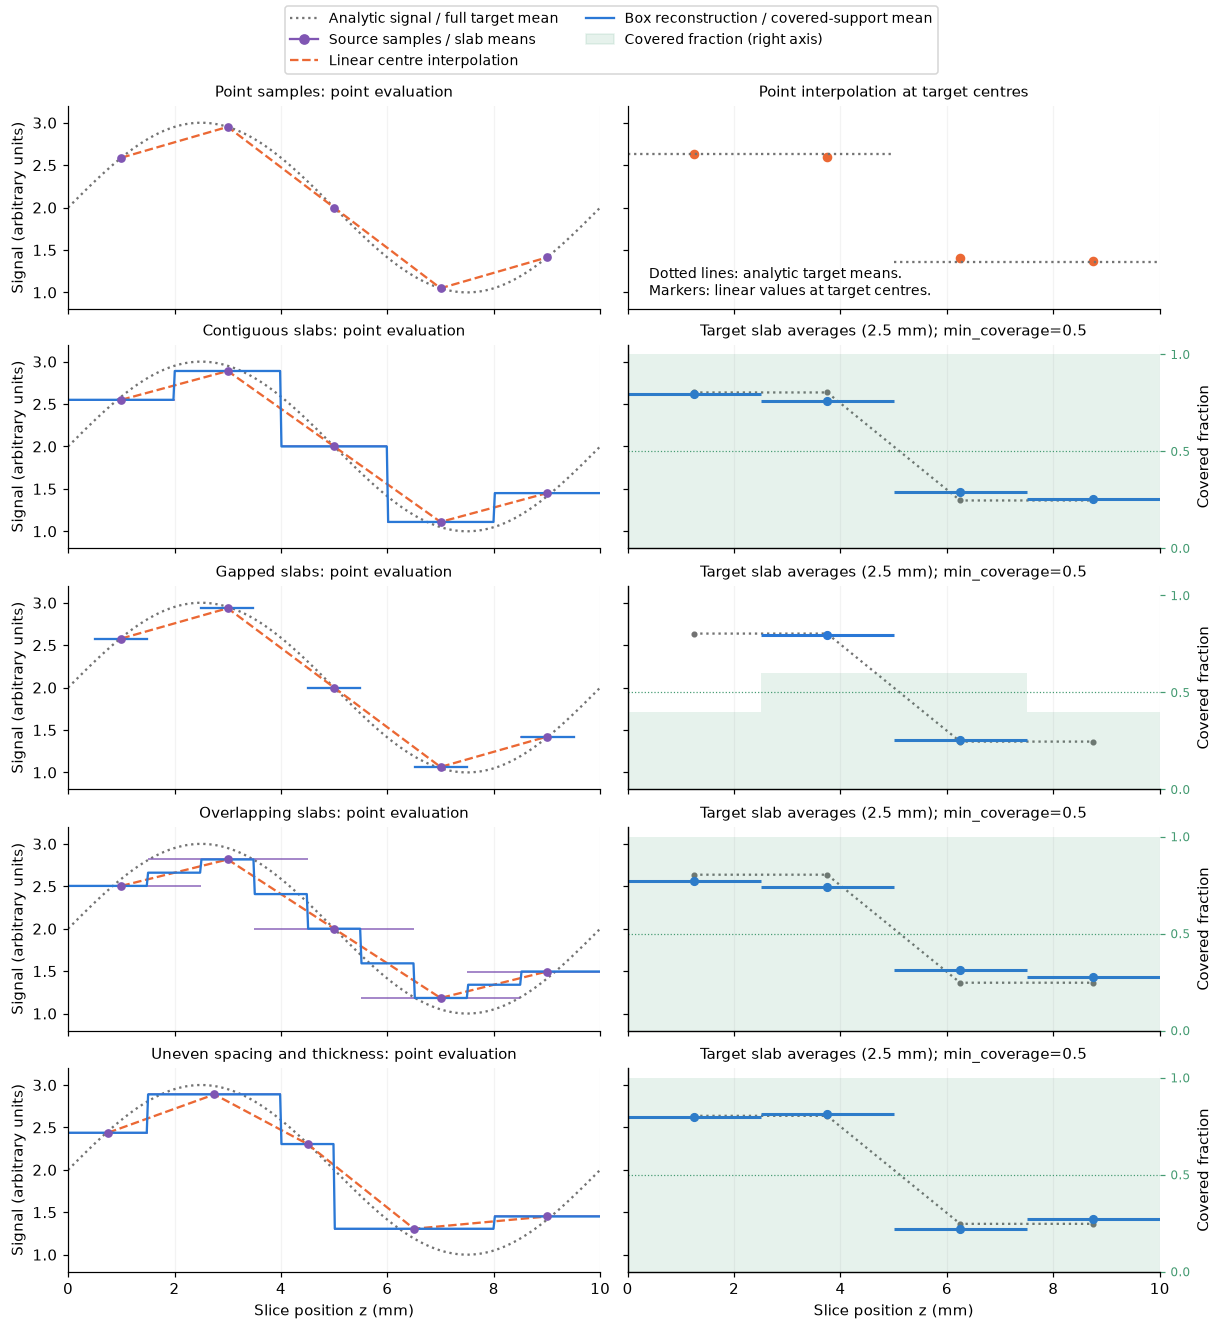

In [19]:
fig, axes = plt.subplots(5, 2, figsize=(11, 12), sharex=True, sharey=True, constrained_layout=True)
for row, (name, source, intervals, interpolant, point_values, average, coverage) in enumerate(
    results
):
    left, right = axes[row]
    left.plot(point_z, signal_at(point_z), color="0.45", ls=":", lw=1.5)
    left.plot(point_z, interpolant.values, color="#eb6834", ls="--", lw=1.5)
    if intervals is not None:
        left.hlines(
            source.values, intervals[:, 0], intervals[:, 1], color="#8056b3", lw=1.3, alpha=0.7
        )
        left.plot(point_z, point_values.values, color="#2a78d6", lw=1.5)
    left.scatter(source.z.values, source.values, color="#8056b3", s=22, zorder=5)
    left.set_title(f"{name}: point evaluation", fontsize=10)
    left.set_ylabel("Signal (arbitrary units)")
    if average is None:
        sampled = source.rf.resample_to(slab_target, method="linear", support="point")
        right.hlines(
            signal_mean(target_intervals),
            target_intervals[:, 0],
            target_intervals[:, 1],
            color="0.45",
            ls=":",
            lw=1.5,
        )
        right.scatter(sampled.z.values, sampled.values, color="#eb6834", s=28)
        right.set_title("Point interpolation at target centres", fontsize=10)
        right.text(
            0.04,
            0.07,
            "Dotted lines: analytic target means.\nMarkers: linear values at target centres.",
            transform=right.transAxes,
            fontsize=9,
        )
    else:
        cov_ax = right.twinx()
        cov_ax.bar(
            average.z.values,
            coverage.values,
            width=2.5,
            color="#459b72",
            alpha=0.13,
            align="center",
        )
        cov_ax.axhline(0.5, color="#459b72", ls=":", lw=0.8)
        cov_ax.set(ylim=(0, 1.05), yticks=[0, 0.5, 1], ylabel="Covered fraction")
        cov_ax.tick_params(axis="y", labelsize=8, colors="#459b72")
        right.plot(
            average.z.values, signal_mean(target_intervals), color="0.45", ls=":", marker="."
        )
        right.hlines(
            average.values, target_intervals[:, 0], target_intervals[:, 1], color="#2a78d6", lw=2
        )
        right.scatter(average.z.values, average.values, color="#2a78d6", s=25, zorder=5)
        right.set_title("Target slab averages (2.5 mm); min_coverage=0.5", fontsize=10)
    for ax in (left, right):
        ax.set(xlim=(0, 10), ylim=(0.8, 3.2), xticks=np.arange(0, 11, 2))
        ax.grid(axis="x", alpha=0.15)
for ax in axes[-1]:
    ax.set_xlabel("Slice position z (mm)")
fig.legend(
    handles=[
        Line2D([], [], color="0.45", ls=":", label="Analytic signal / full target mean"),
        Line2D([], [], color="#8056b3", marker="o", label="Source samples / slab means"),
        Line2D([], [], color="#eb6834", ls="--", label="Linear centre interpolation"),
        Line2D([], [], color="#2a78d6", label="Box reconstruction / covered-support mean"),
        Patch(color="#459b72", alpha=0.13, label="Covered fraction (right axis)"),
    ],
    loc="outside upper center",
    ncol=2,
    fontsize=9,
)
plt.show()

For contiguous slabs, `step` returns each source value inside its declared interval; at a shared
edge, it takes the mean of the adjacent slabs. The averaged result is determined by the lengths
of the source pieces intersecting each target slab. Uneven centre spacing and per-sample
thickness use the same operation when explicit intervals are declared.

For gapped slabs, point evaluation in a gap returns NaN with zero coverage. A partially covered
target can still return a value: this is a mean over measured support, not an estimate of the
missing part of the slab. `return_coverage=True` reports that fraction. The default
`min_coverage=0.5` rejects targets below 50% coverage. In this example the fractions are 0.4,
0.6, 0.6, 0.4, so only the middle two averages are returned. Raising the threshold to 0.75
rejects all four. Linear centre interpolation returns values in those same gaps.

For overlapping slabs, `overlap_mean` first normalizes by the number of covering slabs at each
position, then averages that reconstruction over covered target support. It is not a simple
weighting of source means by their total overlap lengths, and it is not a deconvolution method.
A point at a shared closed interval edge takes the mean of covering slabs. The known analytic
curve and full target means are references for the synthetic experiment, not quantities
recovered exactly by the box reconstruction.

Point results on the dense target grid have no declared intervals. Averaged results retain the
declared target intervals, recording the support represented by their values.

In [20]:
gapped_source = results[2][1]
gap_probe = profile_grid([2.0])
gap_value, gap_coverage = gapped_source.rf.resample_to(
    gap_probe, method="step", support="point", return_coverage=True
)
linear_in_gap = gapped_source.rf.resample_to(gap_probe, method="linear")
print(
    "At z=2 mm: linear =",
    float(linear_in_gap.values[0]),
    "| step =",
    float(gap_value.values[0]),
    "| coverage =",
    float(gap_coverage.values[0]),
)

strict_average = gapped_source.rf.resample_to(
    slab_target, method="step", support="average", min_coverage=0.75
)
print("Target means with min_coverage=0.75:", strict_average.values)
print("Dense point output declares intervals:", bool(results[1][4].rf.grid.intervals))
print(
    "Average output interval widths (mm):",
    np.diff(results[1][5].rf.grid.intervals["z"], axis=1).ravel(),
)

try:
    results[3][1].rf.resample_to(point_target, method="step")
except ValueError as error:
    print("ValueError:", error)

At z=2 mm: linear = 2.7568267286406574 | step = nan | coverage = 0.0
Target means with min_coverage=0.75: [nan nan nan nan]
Dense point output declares intervals: False
Average output interval widths (mm): [2.5 2.5 2.5 2.5]
ValueError: step refuses overlapping source intervals on axis 'z'


#### Averaging adjacent MRI slices

The coronal DICOM series declares 2 mm slice thickness and 2 mm centre spacing. The next example
combines consecutive triplets into nominally 6 mm slabs, keeping the in-plane sampling
unchanged. DICOM image values are integer-valued; box methods require floating values, so the
example converts explicitly. It uses one voxel column from the already loaded `coronal`
array, so no additional dataset is required. Its target intervals use array-coordinate units;
the existing affine maps those intervals into patient space.

In [21]:
column = coronal.isel(j=slice(150, 151), i=slice(80, 81)).astype(float)
column_grid = column.rf.grid
group_centres = np.arange(1.0, column.sizes["k"] - 1, 3.0)
group_intervals = np.column_stack((group_centres - 1.5, group_centres + 1.5))
target_coordinates = dict(column_grid.coordinates)
target_coordinates["k"] = ("k", group_centres)
grouped_grid = xrf.Grid(
    column_grid.transform,
    target_coordinates,
    intervals={"k": group_intervals},
)

slab_means, covered_fraction = column.rf.resample_to(
    grouped_grid, method="step", support="average", return_coverage=True
)
centre_values = column.rf.resample_to(grouped_grid, method="linear", support="point")

source_spacing = float(coronal.rf.geometry.lattice().spacing[0])
positions = np.arange(column.sizes["k"]) * source_spacing
target_positions = group_centres * source_spacing
comparison = pd.DataFrame(
    {
        "Position relative to first slice (mm)": target_positions,
        "Centre-interpolated value": centre_values.values.ravel(),
        "Slab mean (6 mm)": slab_means.values.ravel(),
        "Coverage": covered_fraction.values.ravel(),
    }
)
middle_group = len(comparison) // 2
print(comparison.iloc[middle_group - 3 : middle_group + 3].round(3).to_string(index=False))
print(
    "Source slices:",
    column.sizes["k"],
    "| groups:",
    len(group_centres),
    "| unused trailing slices:",
    column.sizes["k"] - 3 * len(group_centres),
)
print("Source centre spacing (mm):", source_spacing)
print(
    "Source nominal slab thickness (mm):",
    np.diff(column_grid.intervals["k"], axis=1)[0, 0] * source_spacing,
)
print(
    "Linear output nominal slab thickness (mm):",
    np.diff(centre_values.rf.grid.intervals["k"], axis=1)[0, 0] * source_spacing,
)
print(
    "Average output slab thickness (mm):",
    np.diff(slab_means.rf.grid.intervals["k"], axis=1)[0, 0] * source_spacing,
)

 Position relative to first slice (mm)  Centre-interpolated value  Slab mean (6 mm)  Coverage
                                  68.0                      498.0           491.333       1.0
                                  74.0                      451.0           499.333       1.0
                                  80.0                      761.0           919.000       1.0
                                  86.0                     1217.0          1270.000       1.0
                                  92.0                      571.0           629.333       1.0
                                  98.0                      334.0           420.667       1.0
Source slices: 84 | groups: 28 | unused trailing slices: 0
Source centre spacing (mm): 2.0000000587595754
Source nominal slab thickness (mm): 2.0
Linear output nominal slab thickness (mm): 2.0000000000000004
Average output slab thickness (mm): 6.000000176278727


The target centres coincide with every third source slice. The linear call selects the middle
slice of each triplet, while the slab call averages all three slices. The resulting values
generally differ, making the effect of target support visible in the measured MRI data.

Because the linear call selects existing samples, its result retains the selected source slices'
nominal 2 mm intervals. The averaged result instead declares the nominal 6 mm target intervals.
The output table prints both thicknesses, centre spacing, group counts and unused trailing
slices; all source slices are used in this dataset. The in-plane axes retain their source
samples and declare no target intervals, so they pass through unchanged. One voxel column
keeps the example small.

Small deviations from nominal spacing and full coverage reflect the recorded decimal DICOM
geometry. Slice positions in the plot are relative to the first source slice centre.

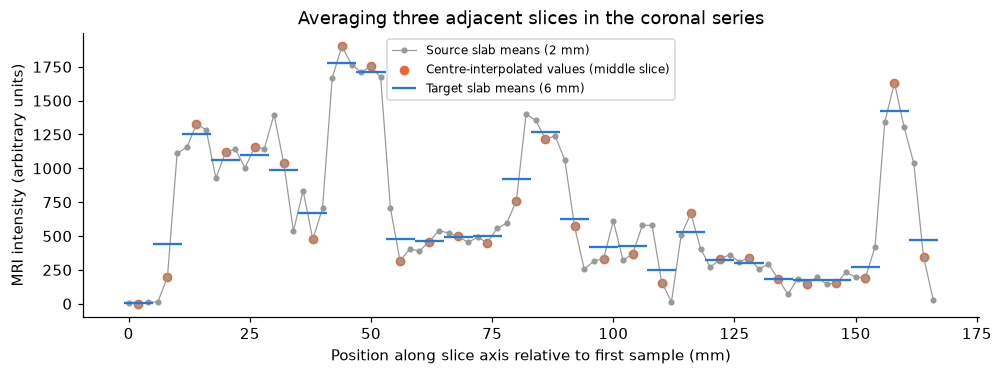

In [22]:
fig, ax = plt.subplots(figsize=(9, 3.3), constrained_layout=True)
ax.plot(
    positions,
    column.values.ravel(),
    color="0.6",
    marker=".",
    lw=0.8,
    label="Source slab means (2 mm)",
)
ax.scatter(
    target_positions,
    centre_values.values.ravel(),
    color="#eb6834",
    s=28,
    label="Centre-interpolated values (middle slice)",
)
ax.hlines(
    slab_means.values.ravel(),
    (group_centres - 1.5) * source_spacing,
    (group_centres + 1.5) * source_spacing,
    color="#2a78d6",
    lw=1.5,
    label="Target slab means (6 mm)",
)
ax.set(
    xlabel="Position along slice axis relative to first sample (mm)",
    ylabel="MRI intensity (arbitrary units)",
    title="Averaging three adjacent slices in the coronal series",
)
ax.legend(fontsize=8)
plt.show()

The current box methods require floating or complex values, declared source intervals on axes
being resampled, and separable affine coordinate mappings. Target averaging also requires
declared intervals on those axes. Axes that select matching source samples can pass through.
This example averages along the original slice axis; it does not use slab averaging to reformat
an oblique stack onto a differently oriented grid. For point interpolation, `domain="cells"`
extends the outer evaluation domain to the declared cell edges; it does not change point
evaluation into target averaging or prevent interpolation across interior gaps. Box methods
already use declared intervals as their domain and reject `domain="cells"`.

### 3.5. Resampling onto a cardinal grid

`anatomy.cardinal_grid` constructs an axial grid with 1 mm spacing that covers the declared
cells of the coronal series. Both the coronal and native axial series are resampled onto this
target.

For the default linear interpolation used here, `domain="cells"` extends evaluation to the outer
source-cell boundaries, holding the edge sample's value within that extension. Interpolation
between sample centres is unchanged.

axial target: {'j': 321, 'k': 169, 'i': 160} SPL


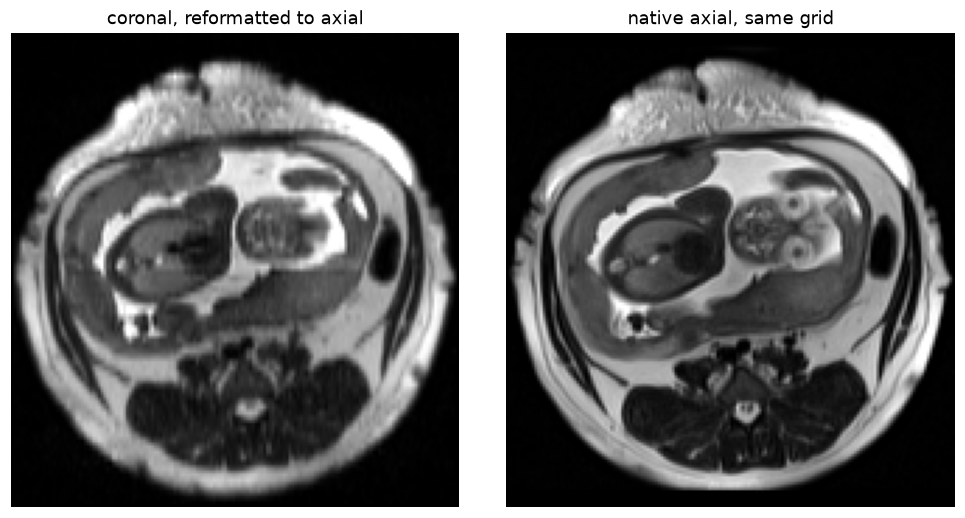

In [23]:
target = anatomy.cardinal_grid(coronal.rf.grid, "axial", spacing=1.0)
print("axial target:", dict(target.sizes), anatomy.orientation_codes(target))

from_coronal = coronal.rf.resample_to(target, domain="cells").compute()
from_axial = axial.rf.resample_to(target, domain="cells").compute()

slice_dim = target.dims[0]  # Dimension increasing in the superior direction
cut = {slice_dim: target.sizes[slice_dim] // 2}
fig, axes = plt.subplots(1, 2, figsize=(9, 4.6), constrained_layout=True)
for ax, (title, array) in zip(
    axes,
    [("coronal, reformatted to axial", from_coronal), ("native axial, same grid", from_axial)],
    strict=True,
):
    ax.imshow(array.isel(cut), cmap=gray, vmin=0, vmax=top)
    ax.set_title(title)
    ax.set_axis_off()
plt.show()

### 3.6. Mapping between voxel and patient coordinates

`point_at` maps an array index position to patient coordinates in millimetres. `positions_at`
maps that point to continuous index positions in the native sagittal and axial grids. These
positions need not be integers or lie within the sampled extent. The queries do not resample
image values.

In [24]:
voxel = dict(k=42, j=150, i=80)
point = coronal.rf.geometry.point_at(**voxel)
print("coronal voxel", voxel, "is at", point.round(1).values, "mm (LPS)")
for name, series in [("sagittal", sagittal), ("axial", axial)]:
    position = series.rf.geometry.positions_at(point.values)
    located = ", ".join(
        f"{dim}={value:.1f}" for dim, value in zip(series.rf.geometry_dims, position, strict=True)
    )
    print(f"  in the native {name} series it is voxel ({located})")

coronal voxel {'k': 42, 'j': 150, 'i': 80} is at [ -1. -65.  10.] mm (LPS)
  in the native sagittal series it is voxel (k=37.8, j=151.0, i=76.2)
  in the native axial series it is voxel (k=43.0, j=81.0, i=159.0)


## 4. Registration transforms and atlas queries

The T1-weighted subject image from OpenNeuro ds000001 is initially assigned an anonymous scanner
frame. The MNI152NLin2009cAsym template and Schaefer 2018 parcellation used here are both
provided in the MNI152NLin2009cAsym template space through TemplateFlow.

Their coded NIfTI geometry is interpreted by the adapter as a shared MNI152 frame. This
metadata-based frame assignment does not estimate a registration or establish that arbitrary
files coded as MNI152 use the same template variant. The subject-to-template relationship is
supplied separately below.

In [25]:
brain = tour_data.brain_images()
subject = nifti.open(brain / "sub-01_T1w.nii.gz")
template = nifti.open(brain / "MNI152NLin2009cAsym_T1w.nii.gz")
atlas = nifti.open(brain / "Schaefer2018_100Parcels7Networks.nii.gz")

print("subject frame:", subject.rf.reference_frame.identifier[0], dict(subject.sizes))
print(
    "template and atlas:",
    template.rf.reference_frame.identifier,
    "shared:",
    template.rf.reference_frame == atlas.rf.reference_frame,
)

subject frame: xarrayrf.anonymous {'i': 160, 'j': 192, 'k': 192}
template and atlas: ('nifti-template', 'MNI152') shared: True


An affine registration computed with SimpleITK is provided in `examples/tour_data.py`;
`tools/register_tour_subject.py` records the procedure used to estimate it. The transform maps
template-frame points to subject-frame points, as required by `resample_to`: each target point
is mapped into the source frame before interpolation. xarrayrf applies the supplied transform;
it does not estimate the registration.

The plots overlay atlas boundaries on the resampled subject image. They illustrate use of the
transform and do not quantify registration accuracy.

In [26]:
mni_to_subject = xrf.AffineTransform.from_matrix(
    source=template.rf.reference_frame,
    target=subject.rf.reference_frame,
    matrix=tour_data.MNI_TO_SUBJECT_MATRIX,
    translation=tour_data.MNI_TO_SUBJECT_TRANSLATION,
)
in_mni = subject.rf.resample_to(template, transform=mni_to_subject).compute()
print(
    "resampled subject: target grid and frame identifier:",
    dict(in_mni.sizes),
    in_mni.rf.reference_frame.identifier,
)

resampled subject: target grid and frame identifier: {'i': 193, 'j': 229, 'k': 193} ('nifti-template', 'MNI152')


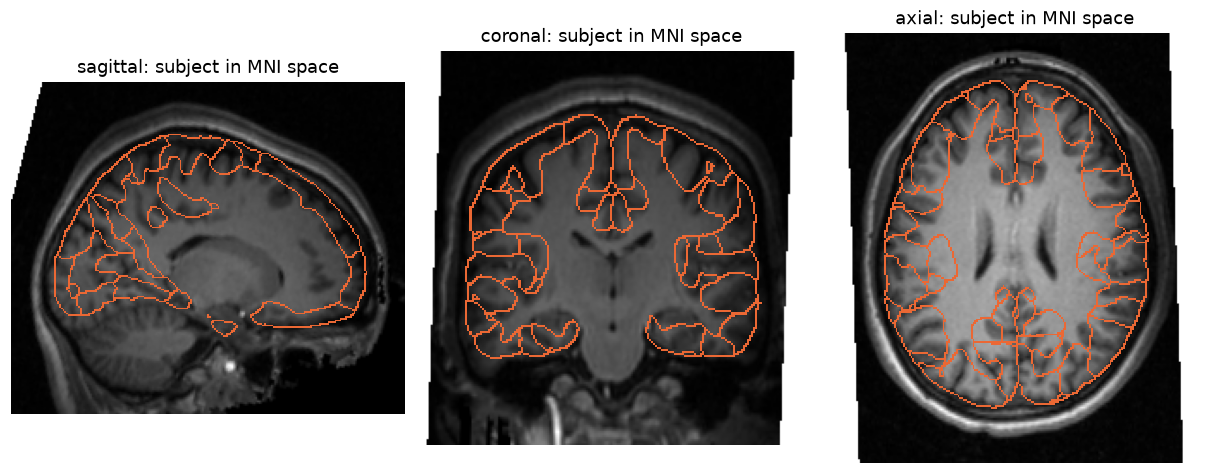

In [27]:
def boundaries(labels):
    """Pixels where the parcel label changes, as a transparent overlay."""
    edge = np.zeros(labels.shape, bool)
    edge[1:, :] |= labels[1:, :] != labels[:-1, :]
    edge[:, 1:] |= labels[:, 1:] != labels[:, :-1]
    return np.ma.masked_where(~edge, edge)


fig, axes = plt.subplots(1, 3, figsize=(11, 4.2), constrained_layout=True)
for ax, (cut, title) in zip(
    axes, [(dict(i=80), "sagittal"), (dict(j=110), "coronal"), (dict(k=100), "axial")], strict=True
):
    ax.imshow(in_mni.isel(cut).values.T, cmap="gray", origin="lower")
    ax.imshow(
        boundaries(atlas.isel(cut).values.T),
        cmap=ListedColormap([ORANGE]),
        origin="lower",
        interpolation="none",
    )
    ax.set_title(f"{title}: subject in MNI space")
    ax.set_axis_off()
plt.show()

To query the atlas from the original subject image, the inverse registration maps a point
from the subject frame into template coordinates. The resulting atlas index position is rounded to the
nearest sample, and the parcel label at that sample is looked up in the label table. This is a
discrete label query rather than interpolation of parcel identifiers.

In [28]:
networks = pd.read_csv(brain / "Schaefer2018_100Parcels7Networks.tsv", sep="\t").set_index("index")[
    "name"
]

voxel = dict(i=69, j=33, k=84)
in_scanner = subject.rf.geometry.point_at(**voxel).values
in_template = mni_to_subject.inverse().transform_point([in_scanner])[0]
position = np.round(atlas.rf.geometry.positions_at(in_template)).astype(int)
parcel = int(atlas.isel(dict(zip(atlas.rf.geometry_dims, position, strict=True))))
print(
    f"subject index {voxel} -> template point {in_template.round(1)} mm -> nearest-sample parcel {networks[parcel]}"
)

subject index {'i': 69, 'j': 33, 'k': 84} -> template point [-10.  -92.6   2.5] mm -> nearest-sample parcel 7Networks_LH_Vis_5


The transform records its source and target frame identities. Applying the transform associated
with sub-01 to sub-02 raises `ValueError` because its endpoints do not match the requested frame
relationship. The check concerns the declared frame identities.

In [29]:
other_subject = nifti.open(brain / "sub-02_T1w.nii.gz")
try:
    other_subject.rf.resample_to(template, transform=mni_to_subject)
except ValueError as error:
    print("ValueError:", error)

ValueError: the transform maps nifti-template:MNI152 to xarrayrf.anonymous:39a2e5febeaa476bac846081ad8b12eb, but this resampling needs nifti-template:MNI152 (target) to xarrayrf.anonymous:a243f7fcc40d4f6b927c3f038fbaff44 (source); a transform applies only to the frames it was computed between


Data sources: OpenNeuro ds000001 (CC0); MNI152NLin2009cAsym template, © 1993–2004 Louis Collins,
McConnell Brain Imaging Centre, MNI, McGill University; Schaefer et al. (2018) parcellation,
obtained through TemplateFlow.

## 5. Geospatial raster resampling and mosaicking

The example reads three public Sentinel-2 true-colour scenes stored as Cloud-Optimized GeoTIFFs,
with 10 m pixel spacing and 10,980 × 10,980 pixels per scene. The scenes are from the same
satellite pass over northern Italy: two adjacent tiles in UTM zone 32N and an overlapping tile
represented in UTM zone 33N.

In [30]:
SCENE = (
    "https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/"
    "{zone}/T/{tile}/2023/8/S2A_{zone}T{tile}_20230821_0_L2A/TCI.tif"
)
west = geotiff.open(SCENE.format(zone=32, tile="PR"))
east = geotiff.open(SCENE.format(zone=32, tile="QR"))
next_zone = geotiff.open(SCENE.format(zone=33, tile="UL"))
print(
    dict(east.sizes),
    "| frames:",
    west.rf.reference_frame.identifier,
    east.rf.reference_frame.identifier,
    next_zone.rf.reference_frame.identifier,
)

{'band': 3, 'row': 10980, 'column': 10980} | frames: ('epsg', '32632') ('epsg', '32632') ('epsg', '32633')


The two zone-32N tiles share a coordinate reference system (CRS), represented by a common frame.
The example defines a 15 km × 15 km target grid in UTM coordinates, straddling the seam between
the tiles, and resamples each tile onto it using nearest-neighbour interpolation.
`combine_first` retains values from the eastern tile and fills missing values from the western
tile.

Remote access retrieves the storage blocks required by the operation rather than downloading the
complete scenes. The plots use easting and northing in kilometres.

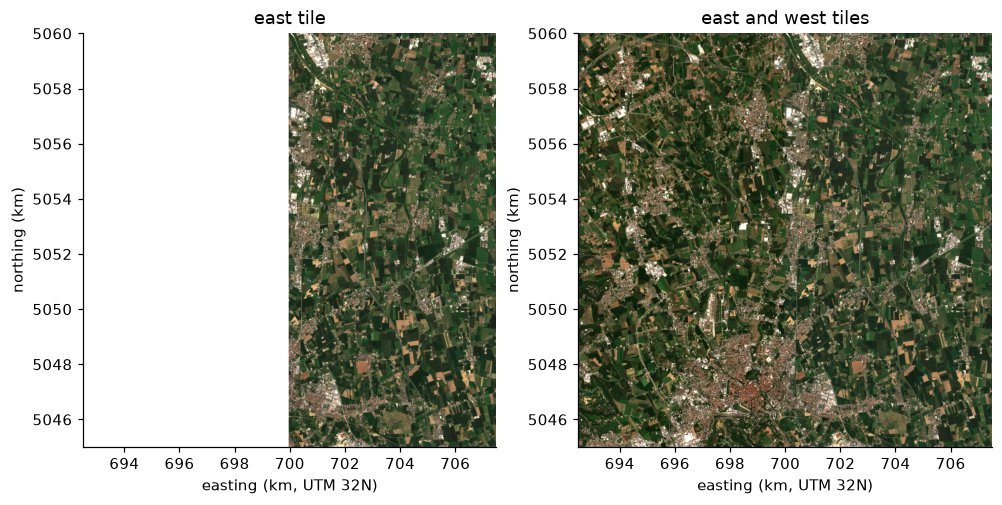

In [31]:
utm32 = east.rf.reference_frame
easting = 692_505.0 + 10.0 * np.arange(1500)  # metres, 10 m pixels
northing = 5_060_005.0 - 10.0 * np.arange(1500)
canvas = xr.DataArray(
    np.zeros((1500, 1500), np.uint8),
    dims=("northing", "easting"),
    coords={"easting": easting, "northing": northing},
).rf.frame(
    xrf.AffineTransform.from_matrix(
        source=xrf.ArrayCoordinates(("easting", "northing"), ("m", "m")),
        target=utm32,
        matrix=np.eye(2),
        translation=[0.0, 0.0],
    ),
    dims=("northing", "easting"),
)

east_only = east.rf.resample_to(canvas, method="nearest").compute()
mosaic = east_only.combine_first(west.rf.resample_to(canvas, method="nearest"))

extent = [easting[0] / 1e3, easting[-1] / 1e3, northing[-1] / 1e3, northing[0] / 1e3]
fig, axes = plt.subplots(1, 2, figsize=(9, 4.6), constrained_layout=True)
for ax, (shown, title) in zip(
    axes, [(east_only, "east tile"), (mosaic, "east and west tiles")], strict=True
):
    rgb = shown.transpose("northing", "easting", "band").values
    ax.imshow(np.nan_to_num(rgb, nan=255).astype(np.uint8), extent=extent)
    ax.set(title=title, xlabel="easting (km, UTM 32N)", ylabel="northing (km)")
plt.show()

The zone-33N tile uses a different projected CRS. Addition to the zone-32N tile raises
`ValueError` because the frames differ. The mapping between these CRSs is nonlinear and cannot
be represented by an `AffineTransform`. Built-in support for geographic reprojection is planned.

In [32]:
try:
    east + next_zone
except ValueError as error:
    print("ValueError:", error)

ValueError: incompatible framed coordinate mappings: the operands are in different reference frames (epsg:32632 and epsg:32633); resample one onto the other with a transform between the frames, or use rf.assume_frame if they are the same space


Contains modified Copernicus Sentinel data 2023.

## 6. Scalar-field resampling under a Lorentz transformation

This synthetic example represents a scalar profile that is constant in time in an object's rest
frame. Coordinates are `(ct, x)`, both in metres. A Lorentz boost maps points from a laboratory
frame into the rest frame for a relative velocity of 0.8c.

The laboratory slice `ct=0` spans a range of rest-frame times, so the source field is sampled
over an extended `ct` range. `resample_to` evaluates the field on this laboratory slice using
cubic interpolation. On this slice, the spatial profile is contracted by a factor of 1/γ, where
γ = 1/√(1−β²) and β = 0.8. The diagnostic compares γ with the ratio of profile widths, defined
here as twice the intensity-weighted standard deviation of position. Finite sampling and
interpolation can affect the numerical agreement.

The example transforms the sampling coordinates of a scalar field. It does not apply a density
normalization or a vector/tensor component transformation.

In [33]:
spacetime = xrf.CoordinateSystem(("ct", "x"), ("m", "m"))
rest = xrf.ReferenceFrame.declared(("demo", "object rest frame"), spacetime)
lab = xrf.ReferenceFrame.declared(("demo", "laboratory"), spacetime)
beta = 0.8
gamma = 1 / np.sqrt(1 - beta**2)
lab_to_rest = xrf.AffineTransform.from_matrix(
    source=lab,
    target=rest,
    translation=[0.0, 0.0],
    matrix=[[gamma, -gamma * beta], [-gamma * beta, gamma]],
)


def spacetime_grid(ct, x, frame):
    array = xr.DataArray(np.zeros((len(ct), len(x))), dims=("ct", "x"), coords={"ct": ct, "x": x})
    identity = xrf.AffineTransform.from_matrix(
        source=xrf.ArrayCoordinates(("ct", "x"), ("m", "m")),
        target=frame,
        matrix=np.eye(2),
        translation=[0.0, 0.0],
    )
    return array.rf.frame(identity, dims=("ct", "x"))


x_rest = np.linspace(-6, 6, 241)
shape = np.exp(-(((x_rest - 1.2) / 0.5) ** 2)) + 0.6 * np.exp(-(((x_rest + 1.5) / 0.9) ** 2))
obj = (
    spacetime_grid(np.linspace(-12, 12, 481), x_rest, rest) + shape
)  # at rest: same shape at every time
lab_now = spacetime_grid([0.0], np.linspace(-3.5, 3.5, 281), lab)  # the lab's instant ct = 0

measured = obj.rf.resample_to(lab_now, transform=lab_to_rest, method="cubic").isel(ct=0)


def width(profile):
    weights = profile / profile.sum()
    centre = (weights * profile.x).sum()
    return float(2 * np.sqrt((weights * (profile.x - centre) ** 2).sum()))


rest_profile = xr.DataArray(shape, dims="x", coords={"x": x_rest})
print(f"length ratio {width(rest_profile) / width(measured):.6f}   Lorentz factor {gamma:.6f}")

length ratio 1.666667   Lorentz factor 1.666667


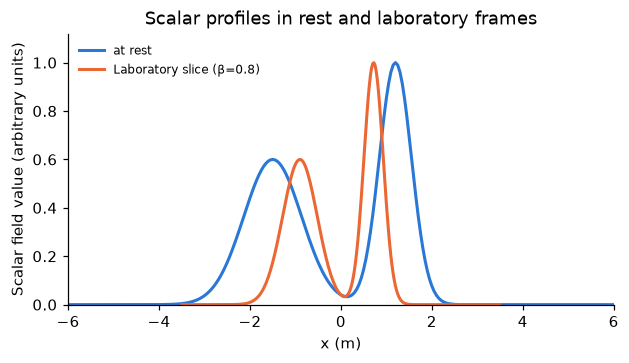

In [34]:
fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.plot(x_rest, shape, color=BLUE, lw=2, label="at rest")
ax.plot(measured.x, measured, color=ORANGE, lw=2, label="Laboratory slice (β=0.8)")
ax.legend(loc="upper left", frameon=False, fontsize=8)
ax.set(xlabel="x (m)", ylabel="Scalar field value (arbitrary units)", xlim=(-6, 6), ylim=(0, 1.12))
ax.set_title("Scalar profiles in rest and laboratory frames")
plt.show()

## 7. Serialization of reference-frame bindings

`rf.encode()` represents the frame binding in serializable array attributes. The following
example writes the encoded array to Zarr, reopens it with xarray, and uses `rf.decode()` to
reconstruct and validate the binding. The printed comparison checks that the coordinate
transform is preserved.

The binding also round-trips through netCDF (tested with the scipy engine); only Zarr is
demonstrated here.

In [35]:
image.rf.encode().to_dataset().to_zarr(workdir / "image.zarr", mode="w", consolidated=False)
restored = xr.open_zarr(workdir / "image.zarr", consolidated=False).section.rf.decode()
print(
    "coordinate transform preserved after Zarr round trip:",
    restored.rf.coordinate_transform == image.rf.coordinate_transform,
)

coordinate transform preserved after Zarr round trip: True


## Implementation status and limitations

xarrayrf is in development and unreleased. Some operations depend on fixes to xarray maintained
as a patch series for upstream submission; the environment commands at the beginning of the
notebook install the pinned patched dependency.

The examples demonstrate affine geometry, explicit frame relationships, geometric queries,
resampling, and serialization. Built-in support for geographic (longitude/latitude) coordinates,
geographic reprojection, and celestial coordinate systems is not yet implemented. Plans and
known limitations are documented in the repository.

Further documentation: [README](../README.md), [interface reference](../docs/core_interface.md),
and [design](../docs/design.md).

## Appendix A. Selected geospatial compatibility observations

The following library observations were reproduced with `tools/geo_failure_modes.py` using
the versions shown. The xarrayrf column summarizes corresponding geometry and compatibility
behavior, covered by the GeoTIFF tests. Later releases may behave differently. These cases
concern metadata and coordinate behavior, rather than overall package capabilities.

| Operation | Library and version | Observed outcome | xarrayrf outcome |
|---|---|---|---|
| Strided `isel`, then locate a pixel with the stored affine | rioxarray 0.23.0 | Stored affine retains the original pixel spacing | Geometry retains the selected source pixel's position |
| Arithmetic across different projected CRSs | rioxarray 0.23.0 | Result retains the first operand's CRS | Raises `ValueError` |
| Join or concatenate raster indexes | rasterix 0.2.2 | CRS is lost; the CRS-less joined index matches a different CRS | Join retains the frame; concatenation of framed geometry axes raises `ValueError` |
| `join="override"` across different projected CRSs | xproj 0.2.1 | The second operand's CRS is replaced by the first | Raises `ValueError` |

The angular-CRS override case in the reproducer is separate: xarrayrf currently rejects angular
CRSs at import, before alignment.